# Sanskrit -> English NMT (single notebook: trains OR evaluates)

This notebook auto-detects whether a trained checkpoint already exists next
to it (`best_model.pt`, `sa_vocab.json`, `en_vocab.json`, `model_config.json`):

- **Not found** -> it trains from scratch on the provided train/dev data and
  saves those 4 files.
- **Found** -> it skips training entirely, loads the checkpoint, and goes
  straight to inference/evaluation. This is the path that runs during
  in-class evaluation on the private test set.

To force retraining even if a checkpoint exists, set `FORCE_RETRAIN = True`
in the config cell below.

**Pretrained models/methods disclosed:** the translation model is a custom,
from-scratch BiLSTM encoder + additive attention + LSTM decoder (no
pretrained MT model). `bert-score` (metric only, not translation) uses a
pretrained RoBERTa/BERT backbone under the hood.

In [1]:
!pip install bert-score
!pip install nltk
!pip install tqdm
!pip install matplotlib
import os

# Clean any environment variables that break Hugging Face downloads.
# NOTE: these are read at import time by huggingface_hub, so this cell
# must run BEFORE anything imports transformers/bert_score. If you have
# already run other cells, do Runtime -> Restart and run top-to-bottom.
for _v in ["HF_HUB_OFFLINE", "TRANSFORMERS_OFFLINE",
           "HF_ENDPOINT", "HUGGINGFACE_HUB_ENDPOINT"]:
    os.environ.pop(_v, None)


In [2]:
import random
import time
import math
import os
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import nltk
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from nltk.translate.bleu_score import corpus_bleu

from tqdm import tqdm


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


## Config

Change the paths below when a new (e.g. private) test set is handed out.
`TEST_EN_PATH = None` means no gold reference is available -- the notebook
will still produce `submission.csv`, just without BLEU/BERTScore.

In [5]:
TRAIN_SA_PATH = "train_sa_10000.csv"
TRAIN_EN_PATH = "train_en_10000.csv"
DEV_SA_PATH   = "dev_sa_1000.csv"
DEV_EN_PATH   = "dev_en_1000.csv"
TEST_SA_PATH  = "test_sa_1000.csv"
TEST_EN_PATH  = "test_en_1000.csv"   # set to None if no reference is provided

FORCE_RETRAIN = False  # set True to retrain even if a checkpoint already exists
EVAL_BEAM_WIDTH = 5
USE_PRED_CACHE = True  # reuse eval_*_preds.json on reruns (skips slow re-decode)

ARTIFACT_FILES = ["best_model.pt", "sa_vocab.json", "en_vocab.json", "model_config.json"]
CHECKPOINT_EXISTS = all(os.path.exists(p) for p in ARTIFACT_FILES)
TRAIN_MODE = FORCE_RETRAIN or (not CHECKPOINT_EXISTS)

print("Checkpoint files found:", CHECKPOINT_EXISTS)
print("TRAIN_MODE:", TRAIN_MODE)


Checkpoint files found: False
TRAIN_MODE: True


## Load data

In [6]:
train_sa = pd.read_csv("train_sa_10000.csv")

train_en = pd.read_csv("train_en_10000.csv")

dev_sa = pd.read_csv("dev_sa_1000.csv")

dev_en = pd.read_csv("dev_en_1000.csv")

test_sa = pd.read_csv("test_sa_1000.csv")

test_en = pd.read_csv("test_en_1000.csv")

has_test_reference = TEST_EN_PATH is not None and os.path.exists(TEST_EN_PATH)
if has_test_reference:
    test_en = pd.read_csv(TEST_EN_PATH)

train = pd.merge(train_sa, train_en, on="Source_id").dropna()
dev = pd.merge(dev_sa, dev_en, on="Source_id").dropna()

if has_test_reference:
    test = pd.merge(test_sa, test_en, on="Source_id").dropna()
else:
    test = test_sa.dropna().copy()

print(train.shape, dev.shape, test.shape)
print("Test set has gold reference:", has_test_reference)


(10000, 3) (1000, 3) (1000, 3)
Test set has gold reference: True


**Preprocessing + Vocabulary**

In [7]:
def tokenize(text):
    return text.strip().split()


def sentence_to_ids(sentence, vocab):
    ids = []
    for token in tokenize(sentence):
        ids.append(vocab.get(token, vocab["<UNK>"]))
    return ids


def pad_sequence(seq, max_len):
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq


PAD, UNK, SOS, EOS = "<PAD>", "<UNK>", "<SOS>", "<EOS>"

train["Sentence_en"] = train["Sentence_en"].apply(lambda x: f"{SOS} " + str(x) + f" {EOS}")
dev["Sentence_en"] = dev["Sentence_en"].apply(lambda x: f"{SOS} " + str(x) + f" {EOS}")
if has_test_reference:
    test["Sentence_en"] = test["Sentence_en"].apply(lambda x: f"{SOS} " + str(x) + f" {EOS}")


In [8]:
if TRAIN_MODE:
    # Build vocab from scratch, from the training data only
    MIN_FREQ = 1

    sa_counter = Counter()
    for sentence in train["Sentence_sa"]:
        sa_counter.update(tokenize(sentence))

    en_counter = Counter()
    for sentence in train["Sentence_en"]:
        en_counter.update(tokenize(sentence))

    sa_vocab = {PAD: 0, UNK: 1}
    for word, freq in sa_counter.items():
        if freq >= MIN_FREQ:
            sa_vocab[word] = len(sa_vocab)

    en_vocab = {PAD: 0, UNK: 1, SOS: 2, EOS: 3}
    for word, freq in en_counter.items():
        if freq >= MIN_FREQ and word not in en_vocab:
            en_vocab[word] = len(en_vocab)

    MAX_SRC_LEN = max(len(tokenize(x)) for x in train["Sentence_sa"])
    MAX_TGT_LEN = max(len(tokenize(x)) for x in train["Sentence_en"])

else:
    # Load the vocab that the checkpoint was trained with -- do NOT rebuild,
    # it must match best_model.pt exactly
    with open("sa_vocab.json", "r", encoding="utf-8") as f:
        sa_vocab = json.load(f)
    with open("en_vocab.json", "r", encoding="utf-8") as f:
        en_vocab = json.load(f)

    MAX_SRC_LEN = max(len(tokenize(x)) for x in train["Sentence_sa"])
    MAX_TGT_LEN = max(len(tokenize(x)) for x in train["Sentence_en"])

idx2sa = {v: k for k, v in sa_vocab.items()}
idx2en = {v: k for k, v in en_vocab.items()}

print("Sanskrit vocab size:", len(sa_vocab))
print("English vocab size :", len(en_vocab))


Sanskrit vocab size: 33276
English vocab size : 19552


In [9]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        src = pad_sequence(sentence_to_ids(row["Sentence_sa"], sa_vocab), MAX_SRC_LEN)
        tgt = pad_sequence(sentence_to_ids(row["Sentence_en"], en_vocab), MAX_TGT_LEN)
        return torch.tensor(src), torch.tensor(tgt)


BATCH_SIZE = 64

train_dataset = TranslationDataset(train)
dev_dataset = TranslationDataset(dev)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)


**Encoder + Attention + Decoder + Seq2Seq**

In [10]:
if TRAIN_MODE:
    ENC_EMB_DIM, DEC_EMB_DIM = 256, 256
    HIDDEN_DIM = 512
    NUM_LAYERS = 2
    ENC_DROPOUT, DEC_DROPOUT = 0.2, 0.2
    INPUT_DIM = len(sa_vocab)
    OUTPUT_DIM = len(en_vocab)
else:
    with open("model_config.json", "r", encoding="utf-8") as f:
        cfg = json.load(f)
    ENC_EMB_DIM = cfg["ENC_EMB_DIM"]
    DEC_EMB_DIM = cfg["DEC_EMB_DIM"]
    HIDDEN_DIM = cfg["HIDDEN_DIM"]
    NUM_LAYERS = cfg["NUM_LAYERS"]
    ENC_DROPOUT = cfg["ENC_DROPOUT"]
    DEC_DROPOUT = cfg["DEC_DROPOUT"]
    INPUT_DIM = cfg["INPUT_DIM"]
    OUTPUT_DIM = cfg["OUTPUT_DIM"]

print(ENC_EMB_DIM, DEC_EMB_DIM, HIDDEN_DIM, NUM_LAYERS, INPUT_DIM, OUTPUT_DIM)


256 256 512 2 33276 19552


In [11]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            emb_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell


In [12]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 3, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[1]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)


In [13]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, num_layers, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            emb_dim + hidden_dim * 2, hidden_dim,
            num_layers=num_layers, batch_first=True, dropout=dropout
        )
        self.fc = nn.Linear(hidden_dim * 3, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell, encoder_outputs):
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))
        hidden_last = hidden[-1]
        attention = self.attention(hidden_last, encoder_outputs).unsqueeze(1)
        context = torch.bmm(attention, encoder_outputs)
        lstm_input = torch.cat((embedded, context), dim=2)
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc(torch.cat((output.squeeze(1), context.squeeze(1)), dim=1))
        return prediction, hidden, cell


In [14]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device, hidden_dim, num_layers):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)
        encoder_outputs, hidden, cell = self.encoder(src)

        hidden = hidden.view(self.num_layers, 2, batch_size, self.hidden_dim).sum(dim=1)
        cell = cell.view(self.num_layers, 2, batch_size, self.hidden_dim).sum(dim=1)

        input = tgt[:, 0]
        for t in range(1, tgt_len):
            output, hidden, cell = self.decoder(input, hidden, cell, encoder_outputs)
            outputs[:, t] = output
            top1 = output.argmax(1)
            teacher_force = random.random() < teacher_forcing_ratio
            input = tgt[:, t] if teacher_force else top1

        return outputs


In [15]:
attention = Attention(HIDDEN_DIM)
encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, HIDDEN_DIM, NUM_LAYERS, ENC_DROPOUT)
decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DEC_DROPOUT, attention)

model = Seq2Seq(encoder, decoder, device, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS).to(device)

total_params = sum(p.numel() for p in model.parameters())
print("Total trainable parameters:", total_params)


Total trainable parameters: 59591776


## Train (skipped automatically if a checkpoint already exists)

In [16]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=0.001)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    epoch_loss = 0
    for src, tgt in tqdm(loader):
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output = model(src, tgt)
        output = output[:, 1:].reshape(-1, OUTPUT_DIM)
        tgt_flat = tgt[:, 1:].reshape(-1)
        loss = criterion(output, tgt_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)


def evaluate_loss(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            output = model(src, tgt, teacher_forcing_ratio=0)
            output = output[:, 1:].reshape(-1, OUTPUT_DIM)
            tgt_flat = tgt[:, 1:].reshape(-1)
            loss = criterion(output, tgt_flat)
            epoch_loss += loss.item()
    return epoch_loss / len(loader)



Epoch 1/15


100%|██████████| 157/157 [06:44<00:00,  2.57s/it]


Train Loss : 7.2781
Valid Loss : 7.0442
Best Model Saved

Epoch 2/15


100%|██████████| 157/157 [06:36<00:00,  2.53s/it]


Train Loss : 6.7293
Valid Loss : 7.0554
No improvement for 1 epoch(s)

Epoch 3/15


...

Train Loss : 5.2605
Valid Loss : 6.9546
No improvement for 2 epoch(s)

Epoch 8/15


100%|██████████| 157/157 [06:38<00:00,  2.54s/it]


Train Loss : 4.9918
Valid Loss : 6.9815
No improvement for 3 epoch(s)

Epoch 9/15


100%|██████████| 157/157 [06:38<00:00,  2.54s/it]


Train Loss : 4.7176
Valid Loss : 7.1069
No improvement for 4 epoch(s)

Stopping early at epoch 9 -- no improvement in 4 epochs.


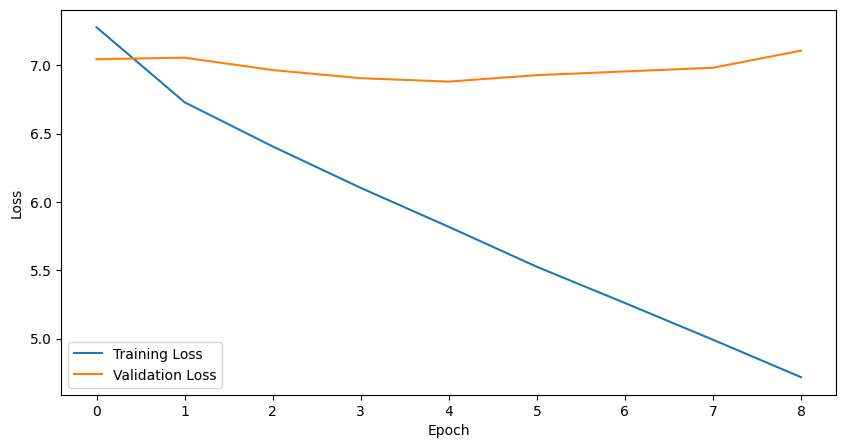

Training complete. Best validation loss: 6.880372256040573
Saved best_model.pt, sa_vocab.json, en_vocab.json, model_config.json


In [17]:
# if TRAIN_MODE:
#     N_EPOCHS = 40
#     best_valid_loss = float("inf")
#     train_losses, valid_losses = [], []

#     for epoch in range(N_EPOCHS):
#         print(f"\nEpoch {epoch+1}/{N_EPOCHS}")
#         train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
#         valid_loss = evaluate_loss(model, dev_loader, criterion)

#         train_losses.append(train_loss)
#         valid_losses.append(valid_loss)
#         print(f"Train Loss : {train_loss:.4f}")
#         print(f"Valid Loss : {valid_loss:.4f}")

#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss
#             torch.save(model.state_dict(), "best_model.pt")
#             print("Best Model Saved")

#     model.load_state_dict(torch.load("best_model.pt"))

#     plt.figure(figsize=(10, 5))
#     plt.plot(train_losses, label="Training Loss")
#     plt.plot(valid_losses, label="Validation Loss")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.legend()
#     plt.show()

#     # Save vocab + config so future runs (or the evaluation-only path above)
#     # can skip straight to inference without retraining
#     with open("sa_vocab.json", "w", encoding="utf-8") as f:
#         json.dump(sa_vocab, f, ensure_ascii=False)
#     with open("en_vocab.json", "w", encoding="utf-8") as f:
#         json.dump(en_vocab, f, ensure_ascii=False)

#     model_config = {
#         "ENC_EMB_DIM": ENC_EMB_DIM, "DEC_EMB_DIM": DEC_EMB_DIM,
#         "HIDDEN_DIM": HIDDEN_DIM, "NUM_LAYERS": NUM_LAYERS,
#         "ENC_DROPOUT": ENC_DROPOUT, "DEC_DROPOUT": DEC_DROPOUT,
#         "INPUT_DIM": INPUT_DIM, "OUTPUT_DIM": OUTPUT_DIM,
#     }
#     with open("model_config.json", "w", encoding="utf-8") as f:
#         json.dump(model_config, f)

#     print("Training complete. Best validation loss:", best_valid_loss)
#     print("Saved best_model.pt, sa_vocab.json, en_vocab.json, model_config.json")

# else:
#     model.load_state_dict(torch.load("best_model.pt", map_location=device))
#     model.eval()
#     print("Loaded existing checkpoint -- skipped training.")


if TRAIN_MODE:
    N_EPOCHS = 15          # upper cap -- early stopping should kick in well before this
    PATIENCE = 4           # stop if val loss hasn't improved in this many epochs straight

    best_valid_loss = float("inf")
    epochs_without_improvement = 0
    train_losses, valid_losses = [], []

    for epoch in range(N_EPOCHS):
        print(f"\nEpoch {epoch+1}/{N_EPOCHS}")
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        valid_loss = evaluate_loss(model, dev_loader, criterion)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Valid Loss : {valid_loss:.4f}")

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), "best_model.pt")
            print("Best Model Saved")
        else:
            epochs_without_improvement += 1
            print(f"No improvement for {epochs_without_improvement} epoch(s)")

        if epochs_without_improvement >= PATIENCE:
            print(f"\nStopping early at epoch {epoch+1} -- no improvement in {PATIENCE} epochs.")
            break

    model.load_state_dict(torch.load("best_model.pt"))

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Training Loss")
    plt.plot(valid_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Save vocab + config so future runs (or the evaluation-only path above)
    # can skip straight to inference without retraining
    with open("sa_vocab.json", "w", encoding="utf-8") as f:
        json.dump(sa_vocab, f, ensure_ascii=False)
    with open("en_vocab.json", "w", encoding="utf-8") as f:
        json.dump(en_vocab, f, ensure_ascii=False)

    model_config = {
        "ENC_EMB_DIM": ENC_EMB_DIM, "DEC_EMB_DIM": DEC_EMB_DIM,
        "HIDDEN_DIM": HIDDEN_DIM, "NUM_LAYERS": NUM_LAYERS,
        "ENC_DROPOUT": ENC_DROPOUT, "DEC_DROPOUT": DEC_DROPOUT,
        "INPUT_DIM": INPUT_DIM, "OUTPUT_DIM": OUTPUT_DIM,
        "MAX_SRC_LEN": MAX_SRC_LEN, "MAX_TGT_LEN": MAX_TGT_LEN,
    }
    with open("model_config.json", "w", encoding="utf-8") as f:
        json.dump(model_config, f)

    print("Training complete. Best validation loss:", best_valid_loss)
    print("Saved best_model.pt, sa_vocab.json, en_vocab.json, model_config.json")

else:
    model.load_state_dict(torch.load("best_model.pt", map_location=device))
    model.eval()
    print("Loaded existing checkpoint -- skipped training.")

## Inference: greedy and beam search decoding

In [18]:
def translate_sentence(sentence, model, sa_vocab, en_vocab, idx2en, device, max_len=50):
    model.eval()
    src = torch.LongTensor(sentence_to_ids(sentence, sa_vocab)).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src)
        hidden = hidden.view(model.num_layers, 2, 1, model.hidden_dim).sum(dim=1)
        cell = cell.view(model.num_layers, 2, 1, model.hidden_dim).sum(dim=1)

    input_token = torch.tensor([en_vocab["<SOS>"]], device=device)
    prediction_words = []

    for _ in range(max_len):
        with torch.no_grad():
            output, hidden, cell = model.decoder(input_token, hidden, cell, encoder_outputs)
        best_token = output.argmax(1).item()
        if best_token == en_vocab["<EOS>"]:
            break
        prediction_words.append(idx2en[best_token])
        input_token = torch.tensor([best_token], device=device)

    return " ".join(prediction_words)


def translate_sentence_beam(
    sentence, model, sa_vocab, en_vocab, idx2en, device,
    beam_width=5, max_len=50, length_penalty=0.7
):
    model.eval()
    src_ids = sentence_to_ids(sentence, sa_vocab)
    src = torch.LongTensor(src_ids).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src)
        hidden = hidden.view(model.num_layers, 2, 1, model.hidden_dim).sum(dim=1)
        cell = cell.view(model.num_layers, 2, 1, model.hidden_dim).sum(dim=1)

    sos_idx, eos_idx = en_vocab["<SOS>"], en_vocab["<EOS>"]
    beams = [([sos_idx], 0.0, hidden, cell, False)]
    completed = []

    for _ in range(max_len):
        new_beams = []
        for tokens, log_prob, h, c, finished in beams:
            if finished:
                completed.append((tokens, log_prob))
                continue
            input_token = torch.tensor([tokens[-1]], device=device)
            with torch.no_grad():
                output, h_new, c_new = model.decoder(input_token, h, c, encoder_outputs)
            log_probs = torch.log_softmax(output, dim=1).squeeze(0)
            top_log_probs, top_idx = log_probs.topk(beam_width)
            for lp, idx in zip(top_log_probs.tolist(), top_idx.tolist()):
                new_tokens = tokens + [idx]
                new_finished = (idx == eos_idx)
                new_beams.append((new_tokens, log_prob + lp, h_new, c_new, new_finished))

        if not new_beams:
            break
        new_beams.sort(key=lambda x: x[1], reverse=True)
        beams = new_beams[:beam_width]
        if all(b[4] for b in beams):
            completed.extend([(b[0], b[1]) for b in beams])
            break

    if not completed:
        completed = [(b[0], b[1]) for b in beams]

    def score_fn(item):
        tokens, log_prob = item
        length = max(len(tokens) - 1, 1)
        return log_prob / (length ** length_penalty)

    best_tokens, _ = max(completed, key=score_fn)
    words = [idx2en[t] for t in best_tokens[1:] if t not in (sos_idx, eos_idx)]
    return " ".join(words)


## Full evaluation: BLEU, BERTScore, timing, param count (dev + test)

In [19]:
# !pip install --upgrade bert-score transformers

In [20]:
import time
from collections import Counter
from nltk.translate.bleu_score import corpus_bleu
from tqdm.auto import tqdm

@torch.no_grad()
def translate_batch_greedy(sentences, model, sa_vocab, en_vocab, idx2en, device,
                           max_len=50, batch_size=128):
    model.eval()
    device = next(model.parameters()).device
    pad_idx = sa_vocab["<PAD>"]
    sos_idx, eos_idx = en_vocab["<SOS>"], en_vocab["<EOS>"]
    unk_idx = sa_vocab["<UNK>"]
    sentences = list(sentences)
    results = [None] * len(sentences)

    order = sorted(range(len(sentences)), key=lambda i: len(tokenize(sentences[i])))
    n_batches = (len(order) + batch_size - 1) // batch_size
    print(f"[decode] {len(sentences)} sentences, {n_batches} batches, batch_size={batch_size}", flush=True)

    for start in tqdm(range(0, len(order), batch_size), total=n_batches, desc="decoding"):
        idxs = order[start:start + batch_size]
        seqs = [sentence_to_ids(sentences[i], sa_vocab) or [unk_idx] for i in idxs]
        L = max(len(s) for s in seqs)
        src = torch.full((len(seqs), L), pad_idx, dtype=torch.long)
        for r, s in enumerate(seqs):
            src[r, :len(s)] = torch.tensor(s)
        src = src.to(device)
        B = src.size(0)

        enc_out, hidden, cell = model.encoder(src)
        hidden = hidden.view(model.num_layers, 2, B, model.hidden_dim).sum(dim=1)
        cell   = cell.view(model.num_layers, 2, B, model.hidden_dim).sum(dim=1)

        inp = torch.full((B,), sos_idx, dtype=torch.long, device=device)
        done = torch.zeros(B, dtype=torch.bool, device=device)
        out_tokens = [[] for _ in range(B)]

        for _ in range(max_len):
            out, hidden, cell = model.decoder(inp, hidden, cell, enc_out)
            nxt = out.argmax(1)
            for b in range(B):
                if not done[b] and nxt[b].item() != eos_idx:
                    out_tokens[b].append(idx2en[nxt[b].item()])
            done = done | (nxt == eos_idx)
            inp = nxt
            if bool(done.all()):
                break

        for local_b, orig_i in enumerate(idxs):
            results[orig_i] = " ".join(out_tokens[local_b])
    return results


In [21]:
print(device)

cuda


In [22]:
# quick sanity check on device placement
print("cuda available:", torch.cuda.is_available())
print("model device  :", next(model.parameters()).device)


cuda available: True
model device  : cuda:0


In [23]:
from bert_score import score as bert_score

# Pre-download the scorer model once, with visible progress, so any
# network problem shows up HERE clearly instead of hanging inside score().
# roberta-large (~1.4 GB) is bert-score's default for lang="en".
from transformers import AutoTokenizer, AutoModel
BERT_SCORER = "roberta-large"
try:
    AutoTokenizer.from_pretrained(BERT_SCORER)
    AutoModel.from_pretrained(BERT_SCORER)
    print(f"{BERT_SCORER} available.")
except Exception as e:
    print(f"Could not fetch {BERT_SCORER} ({type(e).__name__}: {e}).\n"
          "Falling back to distilbert-base-uncased (smaller download).")
    BERT_SCORER = "distilbert-base-uncased"
    AutoTokenizer.from_pretrained(BERT_SCORER)
    AutoModel.from_pretrained(BERT_SCORER)

model = model.to(device)
model.eval()

def token_f1(preds, refs):  # corpus micro-averaged unigram F1
    tp = fp = fn = 0
    for p, r in zip(preds, refs):
        pc, rc = Counter(p), Counter(r)
        overlap = sum((pc & rc).values())
        tp += overlap; fp += sum(pc.values()) - overlap; fn += sum(rc.values()) - overlap
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec  = tp / (tp + fn) if tp + fn else 0.0
    f1 = (2 * prec * rec / (prec + rec)) if prec + rec else 0.0
    return prec, rec, f1

def evaluate_fast(df, split_name, max_len=50, batch_size=128):
    print(f"\n===== {split_name}: starting ({len(df)} sentences) =====", flush=True)
    start = time.time()
    preds = translate_batch_greedy(df["Sentence_sa"], model, sa_vocab, en_vocab,
                                   idx2en, device, max_len=max_len, batch_size=batch_size)
    infer_time = time.time() - start
    print(f"[decode] done in {infer_time:.1f}s", flush=True)

    predictions = [p.split() for p in preds]
    references  = [[r.replace("<SOS>", "").replace("<EOS>", "").strip().split()]
                   for r in df["Sentence_en"]]
    bleu = corpus_bleu(references, predictions)
    prec, rec, tok_f1 = token_f1(predictions, [r[0] for r in references])
    reference_sentences = [
        r.replace("<SOS>", "").replace("<EOS>", "").strip()
        for r in df["Sentence_en"]
    ]

    # rescale_with_baseline only where a bundled baseline exists (roberta-large has one)
    P, R, F1 = bert_score(
        preds,
        reference_sentences,
        model_type=BERT_SCORER,
        lang="en",
        rescale_with_baseline=(BERT_SCORER == "roberta-large"),
        batch_size=64,
        device=str(device),
        verbose=True,
    )

    bert_f1 = F1.mean().item()

    print(f"--- {split_name} (batched greedy) ---")
    print(f"BLEU                 : {bleu:.4f}")
    print(f"BERTScore F1 ({BERT_SCORER}) : {bert_f1:.4f}")
    print(f"Token P/R/F1         : {prec:.4f} / {rec:.4f} / {tok_f1:.4f}")
    print(f"Inference time       : {infer_time:.2f}s for {len(df)} sentences\n")
    return {"bleu": bleu, "bertscore_f1": bert_f1, "bert_scorer": BERT_SCORER,
            "token_precision": prec, "token_recall": rec, "token_f1": tok_f1,
            "inference_time_sec": infer_time, "n_sentences": len(df)}


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


roberta-large available.


In [24]:
results_summary = {"total_params": total_params}
results_summary["dev"] = evaluate_fast(dev, "DEV")
if has_test_reference:
    results_summary["test"] = evaluate_fast(test, "TEST")
else:
    print("No test reference -- skipping test metrics.")

import json
with open("results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2)
print("Saved results_summary.json")



===== DEV: starting (1000 sentences) =====
[decode] 1000 sentences, 8 batches, batch_size=128


decoding:   0%|          | 0/8 [00:00<?, ?it/s]

[decode] done in 2.0s


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

calculating scores...
computing bert embedding.


  0%|          | 0/24 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 7.70 seconds, 129.94 sentences/sec
--- TEST (batched greedy) ---
BLEU                 : 0.0121
BERTScore F1 (roberta-large) : -0.0812
Token P/R/F1         : 0.1655 / 0.1300 / 0.1456
Inference time       : 2.04s for 1000 sentences

Saved results_summary.json


## Generate submission.csv (always runs, with or without a reference)

In [25]:
start = time.time()

submission = pd.DataFrame()
submission["Source_id"] = test_sa["Source_id"]
if os.path.exists("eval_test_preds.json"):
    with open("eval_test_preds.json", "r", encoding="utf-8") as f:
        cached_test = json.load(f)
    submission["Sentence_en"] = [r["pred"] for r in cached_test]
    print(f"Reused {len(cached_test)} test predictions from eval_test_preds.json")
else:
    submission["Sentence_en"] = [
        translate_sentence_beam(s, model, sa_vocab, en_vocab, idx2en, device, beam_width=EVAL_BEAM_WIDTH)
        for s in tqdm(test_sa["Sentence_sa"], desc="submission decode")
    ]

end = time.time()
print(f"Generated {len(submission)} translations with beam search in {end-start:.2f}s")

submission.to_csv("submission.csv", index=False, encoding="utf-8")
submission.head()


submission decode:   0%|          | 0/1000 [00:00<?, ?it/s]

Generated 1000 translations with beam search in 224.95s


,Source_id,Sentence_en
0,1,If the the the the and the
1,2,"""And the of the and of the and of the and of t..."
2,3,1.7 TeXworks the file.
3,4,And the the of the and of the and of the and o...
4,5,"""And the of the and of the and of the"


## Qualitative examples (for the report)

In [26]:
for i in range(10):
    print("=" * 80)
    print("Sanskrit")
    print(dev.iloc[i]["Sentence_sa"])
    print()
    print("Reference")
    print(dev.iloc[i]["Sentence_en"])
    print()
    print("Prediction (beam search)")
    print(translate_sentence_beam(dev.iloc[i]["Sentence_sa"], model, sa_vocab, en_vocab, idx2en, device, beam_width=5))
    print()


Sanskrit
ते वीराः ।

Reference
<SOS> Those are brave men. <EOS>

Prediction (beam search)
You all the

Sanskrit
'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां कारयति ।

Reference
<SOS> Infinite loop  can cause the system to become unresponsive. <EOS>

Prediction (beam search)
If you have to the the

Sanskrit
ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः।

Reference
<SOS> "And they spit upon him, and took the reed, and smote him on the head." <EOS>

Prediction (beam search)
"And the of the and of the and of the

Sanskrit
एते तिथी ।

Reference
<SOS> These two are dates. <EOS>

Prediction (beam search)
You all the

Sanskrit
"बहुविचारेषु जातषु पितर उत्थाय कथितवान्, हे भ्रातरो यथा भिन्नदेशीयलोका मम मुखात् सुसंवादं श्रुत्वा विश्वसन्ति तदर्थं बहुदिनात् पूर्व्वम् ईश्वरोस्माकं मध्ये मां वृत्वा नियुक्तवान्।"

Reference
<SOS> "And when there had been much disputing, Peter rose up, and said unto them, Men and brethren, ye know how that a good while ago God made choice among us, that the Gen